In [15]:
library(io)
library(dplyr)
library(ggplot2)
library(vcfR)
library(broom)

In [16]:
read_vcf <- function(vcf_path, sample_name){

	vcf0 <- read.vcfR(vcf_path, verbose = FALSE)
	vcf1 <- data.frame(
		Chr = getCHROM(vcf0),
		Pos = getPOS(vcf0),
		Ref = getREF(vcf0),
		Alt = getALT(vcf0),
		filter = getFILTER(vcf0)
		# ad = as.vector(extract.gt(vcf0, element = "AD")[, sample_name]),
		# f1r1 = as.vector(extract.gt(vcf0, element = "F1R2")[, sample_name]),
		# f2r1 = as.vector(extract.gt(vcf0, element = "F2R1")[, sample_name]),
		# dp = as.vector(extract.gt(vcf0, element = "DP")[, sample_name])
	)
	return(vcf1)
}

In [17]:
get_arti_summary <- function(dataset, msec_variant_set, annot_path, msec_col = "msec_filter_1234", vcf_variant_set = NULL){

	message(sprintf("Processing: Dataset: %s | MicroSEC Variant Set: %s | MicroSEC Artifact Column = %s", dataset, msec_variant_set, msec_col))
	message(sprintf("Variants from MicroSEC results will be subsetted with variants from VCF variant set: '%s' before calculation", vcf_variant_set))

	vcf_root <- file.path("../vcf", dataset, msec_variant_set)
	res_paths <- Sys.glob(sprintf("%s/%s/*/*.microsec.tsv", dataset, msec_variant_set))
	annot <- read.delim(annot_path)[, c("sample_name", "preservation")]

	summary <- list()

	for (i in seq_along(res_paths)){
		msec_path <- res_paths[i]
		sample_name <- unlist(strsplit(basename(msec_path), "\\."))[1]
		
		message(sprintf("%d. Processing sample: %s", i, sample_name))

		res <- read.delim(msec_path)

		if (!is.null(vcf_variant_set)){
			## Read VCF with variants after all the other filtering stages i.e PASS, exome, blacklist
			vcf_path <- file.path(vcf_root, sample_name, sprintf("%s.vcf.gz", sample_name))
			vcf <- read_vcf(vcf_path)
			## Filter variants that were removed by the aforementioned filters
			res <- semi_join(res, vcf, by=c("Chr", "Pos", "Ref", "Alt"))
		}

		## Select the artifacts identified by MicroSEC
		arti <- subset(res, get(msec_col) == "Artifact suspicious")
		
		sample_stats <- data.frame(
			sample_name = sample_name,
			variants = nrow(res),
			artifacts = nrow(arti),
			arti_pct = round((nrow(arti) / nrow(res)) * 100, 2)
		)

		summary[[i]] <- sample_stats
	}

	summary_df <- bind_rows(summary)
	msec_summary <- merge(summary_df, annot, by = "sample_name")

	return(msec_summary)

}

## Chong21

In [18]:
chong21_summary <- get_arti_summary(
	dataset = "PRJEB44073",
	msec_variant_set = "filtered_pass-orientation-exome", 
	annot_path = "../annot/PRJEB44073/sample-info_stage3.tsv",
	vcf_variant_set = "filtered_pass-orientation-exome-blacklist-macni"
)

qwrite(chong21_summary, "summary/chong21_pass-exome-blacklist_micr-summary.tsv")

Processing: Dataset: PRJEB44073 | MicroSEC Variant Set: filtered_pass-orientation-exome | MicroSEC Artifact Column = msec_filter_1234

Variants from MicroSEC results will be subsetted with variants from VCF variant set: 'filtered_pass-orientation-exome-blacklist-macni' before calculation

1. Processing sample: Sample_B83_0001

2. Processing sample: Sample_B83_0002

3. Processing sample: Sample_B83_0003

4. Processing sample: Sample_B83_0004

5. Processing sample: Sample_B83_0005

6. Processing sample: Sample_B83_0006

7. Processing sample: Sample_B83_0007

8. Processing sample: Sample_B83_0008

9. Processing sample: Sample_B83_0010

10. Processing sample: Sample_B83_0011

11. Processing sample: Sample_B83_0012

12. Processing sample: Sample_B83_0013

13. Processing sample: Sample_B83_0014

14. Processing sample: Sample_B83_0015

15. Processing sample: Sample_B83_0016

16. Processing sample: Sample_B83_0017

17. Processing sample: Sample_B83_0018

18. Processing sample: Sample_B83_0019


In [19]:
chong21_summary

sample_name,variants,artifacts,arti_pct,preservation
<chr>,<int>,<int>,<dbl>,<chr>
Sample_B83_0001,20917,3831,18.32,Frozen
Sample_B83_0002,10297,283,2.75,Frozen
Sample_B83_0003,5824,772,13.26,Frozen
Sample_B83_0004,8066,253,3.14,Frozen
Sample_B83_0005,1600,113,7.06,Frozen
Sample_B83_0006,4020,295,7.34,Frozen
Sample_B83_0007,2778,185,6.66,Frozen
Sample_B83_0008,2464,140,5.68,Frozen
Sample_B83_0010,45291,1258,2.78,Frozen


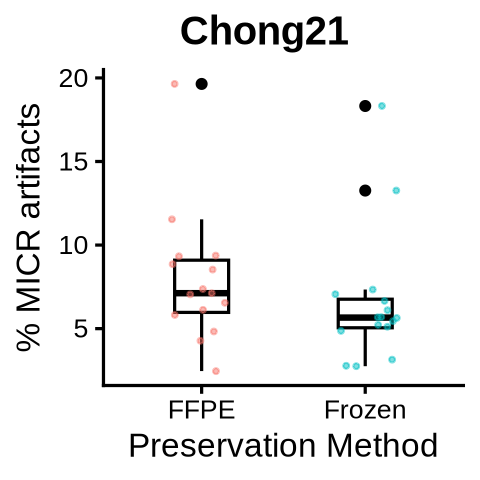

In [20]:
options(repr.plot.width = 4, repr.plot.height = 4)

chong21_pct <- ggplot(chong21_summary, aes(x = preservation, y = arti_pct, color = preservation)) +
	geom_boxplot(width = 0.33, color = "black") +
	geom_jitter(size = 1, alpha = 0.5, width = 0.2) +
	theme_classic(base_size = 20) +
	labs(
		title = "Chong21",
		x = "Preservation Method",
		y = "% MICR artifacts"
	) +
	theme(
		legend.position = "none",
		plot.title = element_text(hjust = 0.4, face = "bold")
	)

chong21_pct
qdraw(chong21_pct, "summary/chong21_pass-exome-blacklist-macni_micr-pct.pdf", height = 4, width = 4)

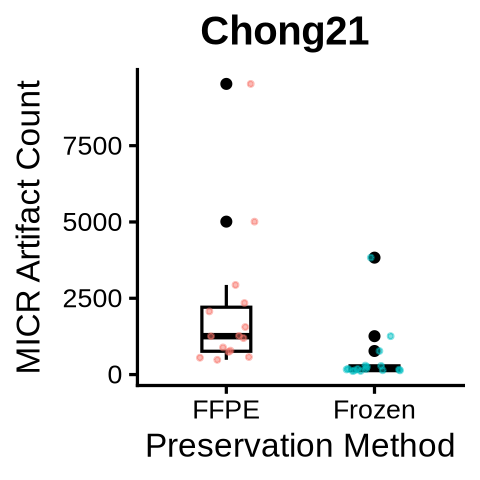

In [21]:
options(repr.plot.width = 4, repr.plot.height = 4)

chong21_count <- ggplot(chong21_summary, aes(x = preservation, y = artifacts, color = preservation)) +
	geom_boxplot(width = 0.33, color = "black") +
	geom_jitter(size = 1, alpha = 0.5, width = 0.2) +
	theme_classic(base_size = 20) +
	labs(
		title = "Chong21",
		x = "Preservation Method",
		y = "MICR Artifact Count"
	) +
	theme(
		legend.position = "none",
		plot.title = element_text(hjust = 0.4, face = "bold")
	)

chong21_count
qdraw(chong21_count, "summary/chong21_pass-exome-blacklist-macni_micr-count.pdf", height = 4, width = 4)

In [34]:
# wilcox.test(arti_pct ~ preservation, data = chong21_summary)
chong21_wilcox <- wilcox.test(artifacts ~ preservation, data = chong21_summary)
print(chong21_wilcox)

qwrite(tidy(chong21_wilcox), "summary/chong21_pass-exome-blacklist-macni_wilcox-test.tsv")

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”



	Wilcoxon rank sum test with continuity correction

data:  artifacts by preservation
W = 215.5, p-value = 0.0001727
alternative hypothesis: true location shift is not equal to 0



## Oh15

In [23]:
oh15_summary <- get_arti_summary(
	dataset = "SRP065941",
	msec_variant_set = "filtered_pass-orientation", 
	annot_path = "../annot/SRP065941/sample_annotation_stage2_tumor-only.tsv",
	vcf_variant_set = "filtered_pass-orientation-exome-blacklist"
)

qwrite(oh15_summary, "summary/oh15_pass-exome-blacklist_micr-summary.tsv")

Processing: Dataset: SRP065941 | MicroSEC Variant Set: filtered_pass-orientation | MicroSEC Artifact Column = msec_filter_1234

Variants from MicroSEC results will be subsetted with variants from VCF variant set: 'filtered_pass-orientation-exome-blacklist' before calculation

1. Processing sample: T1_FFPE

2. Processing sample: T1_frozen

3. Processing sample: T2_FFPE

4. Processing sample: T2_frozen

5. Processing sample: T3_FFPE

6. Processing sample: T3_frozen

7. Processing sample: T4_2007_FFPE

8. Processing sample: T4_2009_FFPE

9. Processing sample: T4_frozen



In [24]:
oh15_summary

sample_name,variants,artifacts,arti_pct,preservation
<chr>,<int>,<int>,<dbl>,<chr>
T1_FFPE,2403,36,1.50,FFPE
T1_frozen,960,12,1.25,Frozen
T2_FFPE,8294,1027,12.38,FFPE
T2_frozen,206,17,8.25,Frozen
T3_FFPE,9265,1259,13.59,FFPE
T3_frozen,166,31,18.67,Frozen
T4_2007_FFPE,15637,192,1.23,FFPE
T4_2009_FFPE,17133,4725,27.58,FFPE
T4_frozen,383,9,2.35,Frozen


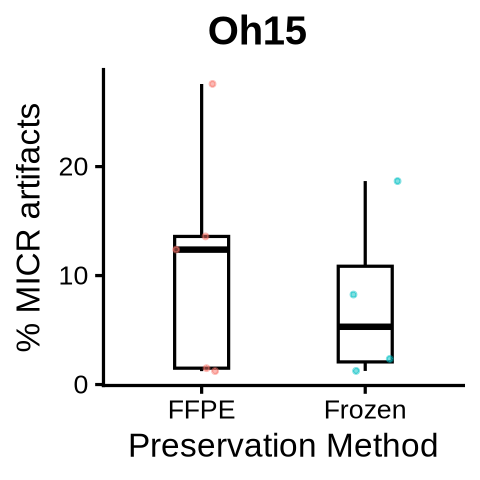

In [25]:
options(repr.plot.width = 4, repr.plot.height = 4)

oh15_pct <- ggplot(oh15_summary, aes(x = preservation, y = arti_pct, color = preservation)) +
	geom_boxplot(width = 0.33, color = "black") +
	geom_jitter(size = 1, alpha = 0.5, width = 0.2) +
	theme_classic(base_size = 20) +
	labs(
		title = "Oh15",
		x = "Preservation Method",
		y = "% MICR artifacts"
	) +
	theme(
		legend.position = "none",
		plot.title = element_text(hjust = 0.4, face = "bold")
	)

oh15_pct
qdraw(oh15_pct, "summary/oh15_pass-exome-blacklist-macni_micr-pct.pdf", height = 4, width = 4)

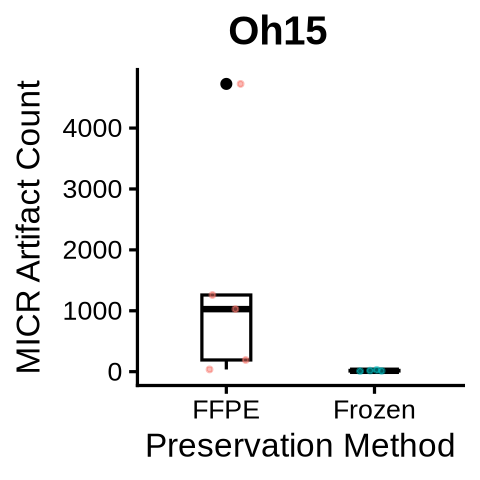

In [26]:
options(repr.plot.width = 4, repr.plot.height = 4)

oh15_count <- ggplot(oh15_summary, aes(x = preservation, y = artifacts, color = preservation)) +
	geom_boxplot(width = 0.33, color = "black") +
	geom_jitter(size = 1, alpha = 0.5, width = 0.2) +
	theme_classic(base_size = 20) +
	labs(
		title = "Oh15",
		x = "Preservation Method",
		y = "MICR Artifact Count"
	) +
	theme(
		legend.position = "none",
		plot.title = element_text(hjust = 0.4, face = "bold")
	)

oh15_count
qdraw(oh15_count, "summary/oh15_pass-exome-blacklist-macni_micr-count.pdf", height = 4, width = 4)

In [33]:
# wilcox.test(arti_pct ~ preservation, data = oh15_summary)
oh15_wilcox <- wilcox.test(artifacts ~ preservation, data = oh15_summary)
print(oh15_wilcox)

qwrite(tidy(oh15_wilcox), "summary/oh15_pass-exome-blacklist-macni_wilcox-test.tsv")


	Wilcoxon rank sum exact test

data:  artifacts by preservation
W = 20, p-value = 0.01587
alternative hypothesis: true location shift is not equal to 0



## SRP044740

In [28]:
srp044740_summary <- get_arti_summary(
	dataset = "SRP044740",
	msec_variant_set = "filtered_pass-orientation-exome-blacklist-macni", 
	annot_path = "../annot/SRP044740/sample-info_stage2.tsv"
)

qwrite(srp044740_summary, "summary/srp044740_pass-exome-blacklist_micr-summary.tsv")

Processing: Dataset: SRP044740 | MicroSEC Variant Set: filtered_pass-orientation-exome-blacklist-macni | MicroSEC Artifact Column = msec_filter_1234



1. Processing sample: BGI-FFPE10_SRR1523246

2. Processing sample: BGI-FFPE10_SRR1523265

3. Processing sample: BGI-FFPE11_SRR1523250

4. Processing sample: BGI-FFPE11_SRR1523258

5. Processing sample: BGI-FFPE12_SRR1523248

6. Processing sample: BGI-FFPE12_SRR1523259

7. Processing sample: BGI-FFPE13_SRR1523267

8. Processing sample: BGI-FFPE1_SRR1523243

9. Processing sample: BGI-FFPE1_SRR1523263

10. Processing sample: BGI-FFPE2_SRR1523264

11. Processing sample: BGI-FFPE3_SRR1523269

12. Processing sample: BGI-FFPE4_SRR1523268

13. Processing sample: BGI-FFPE5_SRR1523252

14. Processing sample: BGI-FFPE8_SRR1523245

15. Processing sample: BGI-FFPE8_SRR1523262

16. Processing sample: BGI-FFPE9_SRR1523255

17. Processing sample: BGI-FROZ10_SRR1523233

18. Processing sample: BGI-FROZ11_SRR1523236

19. Processing sample: BGI-FROZ12_SRR1

In [29]:
srp044740_summary

sample_name,variants,artifacts,arti_pct,preservation
<chr>,<int>,<int>,<dbl>,<chr>
BGI-FFPE1_SRR1523243,69767,38046,54.53,FFPE
BGI-FFPE1_SRR1523263,17327,8891,51.31,FFPE
BGI-FFPE10_SRR1523246,64647,33277,51.47,FFPE
BGI-FFPE10_SRR1523265,26612,2689,10.10,FFPE
BGI-FFPE11_SRR1523250,54397,7016,12.90,FFPE
BGI-FFPE11_SRR1523258,61371,219,0.36,FFPE
BGI-FFPE12_SRR1523248,34221,2904,8.49,FFPE
BGI-FFPE12_SRR1523259,31669,360,1.14,FFPE
BGI-FFPE13_SRR1523267,84529,5573,6.59,FFPE


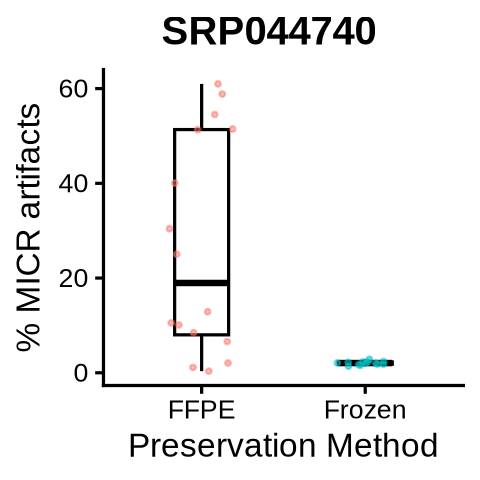

In [30]:
options(repr.plot.width = 4, repr.plot.height = 4)

srp044740_pct <- ggplot(srp044740_summary, aes(x = preservation, y = arti_pct, color = preservation)) +
	geom_boxplot(width = 0.33, color = "black") +
	geom_jitter(size = 1, alpha = 0.5, width = 0.2) +
	theme_classic(base_size = 20) +
	labs(
		title = "SRP044740",
		x = "Preservation Method",
		y = "% MICR artifacts"
	) +
	theme(
		legend.position = "none",
		plot.title = element_text(hjust = 0.4, face = "bold")
	)

srp044740_pct
qdraw(srp044740_pct, "summary/srp044740_pass-exome-blacklist-macni_micr-pct.pdf", height = 4, width = 4)

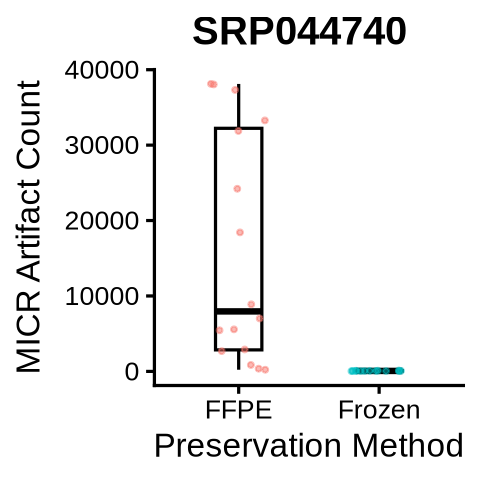

In [31]:
options(repr.plot.width = 4, repr.plot.height = 4)

srp044740_count <- ggplot(srp044740_summary, aes(x = preservation, y = artifacts, color = preservation)) +
	geom_boxplot(width = 0.33, color = "black") +
	geom_jitter(size = 1, alpha = 0.5, width = 0.2) +
	theme_classic(base_size = 20) +
	labs(
		title = "SRP044740",
		x = "Preservation Method",
		y = "MICR Artifact Count"
	) +
	theme(
		legend.position = "none",
		plot.title = element_text(hjust = 0.4, face = "bold")
	)

srp044740_count
qdraw(srp044740_count, "summary/srp044740_pass-exome-blacklist-macni_micr-count.pdf", height = 4, width = 4)

In [32]:
# wilcox.test(arti_pct ~ preservation, data = srp044740_summary)
srp044740_wilcox <- wilcox.test(artifacts ~ preservation, data = srp044740_summary)
print(srp044740_wilcox)

qwrite(tidy(srp044740_wilcox), "summary/srp044740_pass-exome-blacklist-macni_wilcox-test.tsv")


	Wilcoxon rank sum exact test

data:  artifacts by preservation
W = 208, p-value = 2.947e-08
alternative hypothesis: true location shift is not equal to 0

